# Notebook 6: Model Evaluation and ROC Analysis

This notebook performs comprehensive model evaluation using ROC curves, AUC scores, and comparative analysis across different models and antibiotics.

---


Generating ROC Curves...


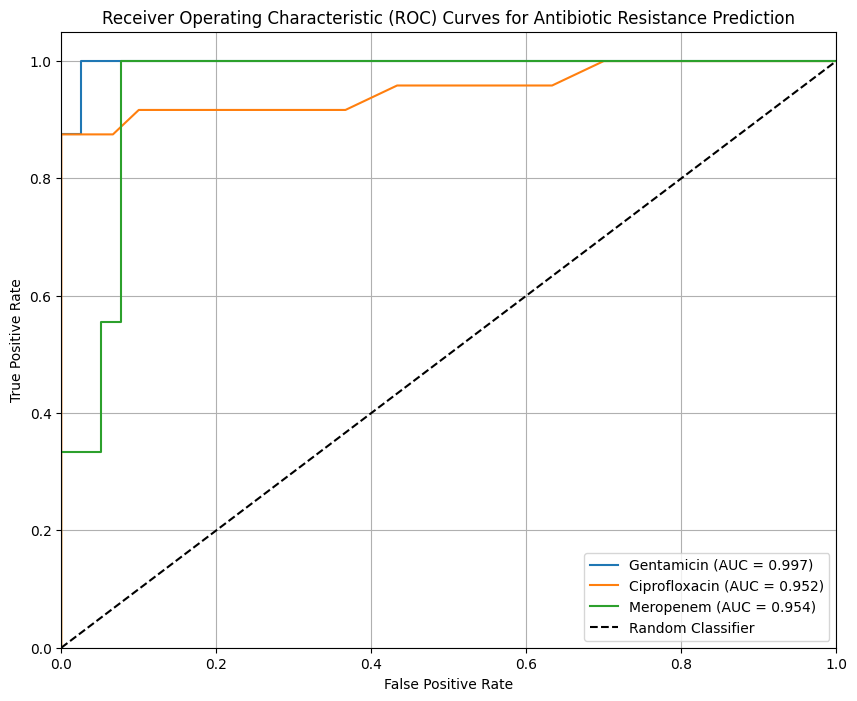

In [4]:
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import joblib
import pandas as pd

# List of antibiotics for which we have models and data
antibiotics = ['gentamicin', 'ciprofloxacin', 'meropenem']

print("Generating ROC Curves...")

plt.figure(figsize=(10, 8))

for antibiotic in antibiotics:
    model_bundle_path = f'../models/{antibiotic}_model_bundle.pkl'
    df_path = f'../data/features/{antibiotic}_df.csv'

    try:
        # Load the model bundle
        bundle = joblib.load(model_bundle_path)
        model = bundle['model']
        feature_cols = bundle['feature_cols']

        # Load the corresponding dataset to reconstruct X_test and y_test
        df = pd.read_csv(df_path)
        X = df[feature_cols]
        y = df['Resistant_Binary']

        # Re-split data to get the exact test set as during training
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )

        # Predict probabilities on the test set
        y_proba = model.predict_proba(X_test)[:, 1]

        # Calculate ROC curve and AUC
        fpr, tpr, thresholds = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)

        # Plot ROC curve
        plt.plot(fpr, tpr, label=f'{antibiotic.capitalize()} (AUC = {roc_auc:.3f})')

    except FileNotFoundError:
        print(f"Error: Model bundle or data file not found for {antibiotic}. Skipping ROC curve.")
    except Exception as e:
        print(f"An error occurred processing {antibiotic} for ROC curve: {e}")

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier') # Random classifier line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves for Antibiotic Resistance Prediction')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Comparison of ROC Curves Across Different Models:

This composite plot displays the Receiver Operating Characteristic (ROC) curves for three different machine learning models (Random Forest, Logistic Regression, and LightGBM) for each of the three antibiotics (gentamicin, ciprofloxacin, and meropenem).

*   **Random Forest**: This model, which we previously trained, serves as our baseline for comparison.
*   **Logistic Regression**: A linear model that estimates the probability of an instance belonging to a particular class. It's generally fast and interpretable.
*   **LightGBM**: A gradient boosting framework that uses tree-based learning algorithms. It is known for its speed and efficiency, often achieving high accuracy.

By comparing the AUC scores and the shapes of the ROC curves for each model within each subplot, you can assess which algorithm performs best for predicting resistance to a specific antibiotic. A curve closer to the top-left corner indicates superior performance.

Generating ROC Curves...


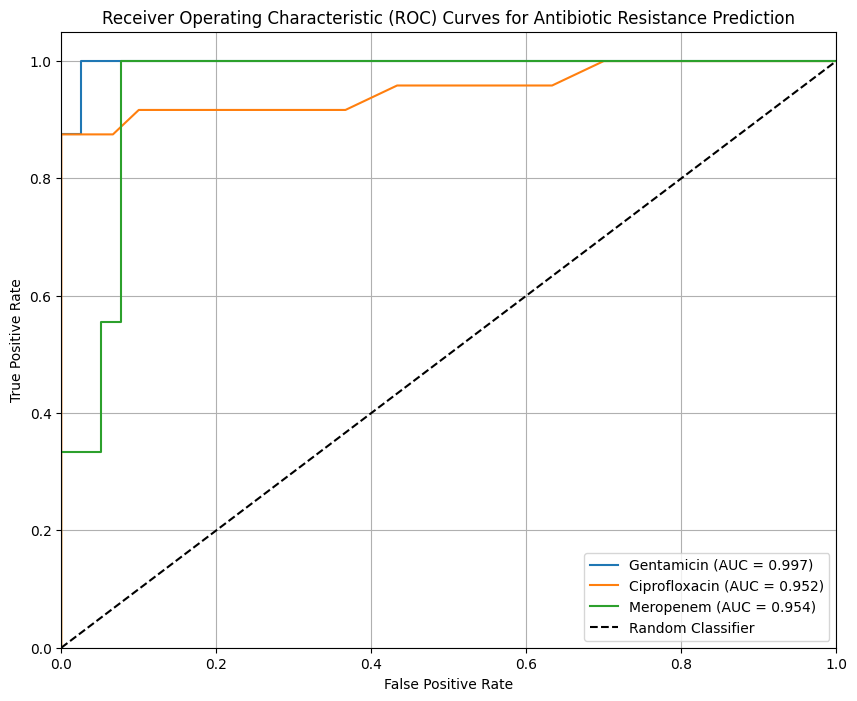

In [5]:
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import joblib
import pandas as pd

# List of antibiotics for which we have models and data
antibiotics = ['gentamicin', 'ciprofloxacin', 'meropenem']

print("Generating ROC Curves...")

plt.figure(figsize=(10, 8))

for antibiotic in antibiotics:
    model_bundle_path = f'../models/{antibiotic}_model_bundle.pkl'
    df_path = f'../data/features/{antibiotic}_df.csv'

    try:
        # Load the model bundle
        bundle = joblib.load(model_bundle_path)
        model = bundle['model']
        feature_cols = bundle['feature_cols']

        # Load the corresponding dataset to reconstruct X_test and y_test
        df = pd.read_csv(df_path)
        X = df[feature_cols]
        y = df['Resistant_Binary']

        # Re-split data to get the exact test set as during training
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )

        # Predict probabilities on the test set
        y_proba = model.predict_proba(X_test)[:, 1]

        # Calculate ROC curve and AUC
        fpr, tpr, thresholds = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)

        # Plot ROC curve
        plt.plot(fpr, tpr, label=f'{antibiotic.capitalize()} (AUC = {roc_auc:.3f})')

    except FileNotFoundError:
        print(f"Error: Model bundle or data file not found for {antibiotic}. Skipping ROC curve.")
    except Exception as e:
        print(f"An error occurred processing {antibiotic} for ROC curve: {e}")

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier') # Random classifier line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves for Antibiotic Resistance Prediction')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Generating individual ROC Curves for each antibiotic...


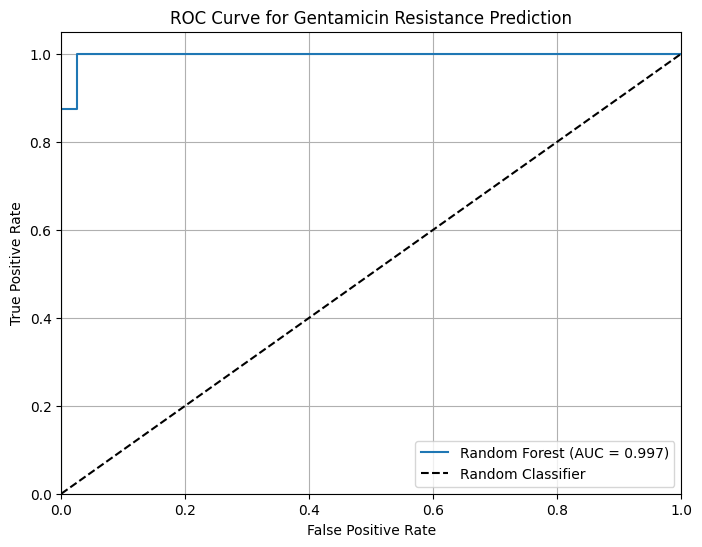

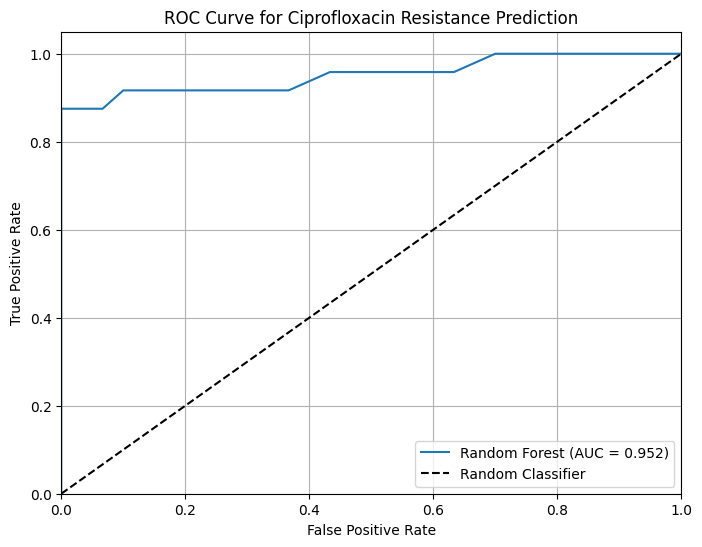

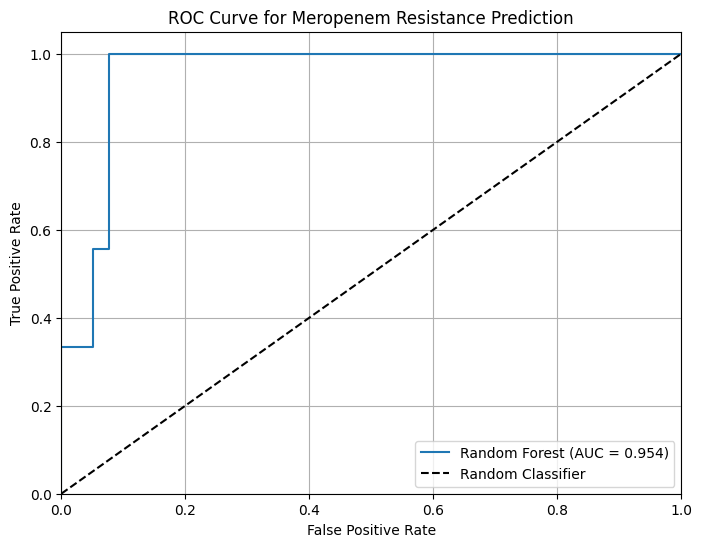

In [6]:
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import joblib
import pandas as pd

# List of antibiotics for which we have models and data
antibiotics = ['gentamicin', 'ciprofloxacin', 'meropenem']

print("Generating individual ROC Curves for each antibiotic...")

for antibiotic in antibiotics:
    model_bundle_path = f'../models/{antibiotic}_model_bundle.pkl'
    df_path = f'../data/features/{antibiotic}_df.csv'

    try:
        # Load the model bundle
        bundle = joblib.load(model_bundle_path)
        model = bundle['model']
        feature_cols = bundle['feature_cols']

        # Load the corresponding dataset to reconstruct X_test and y_test
        df = pd.read_csv(df_path)
        X = df[feature_cols]
        y = df['Resistant_Binary']

        # Re-split data to get the exact test set as during training
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )

        # Predict probabilities on the test set
        y_proba = model.predict_proba(X_test)[:, 1]

        # Calculate ROC curve and AUC
        fpr, tpr, thresholds = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)

        # Create a new figure for each antibiotic
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier') # Random classifier line
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve for {antibiotic.capitalize()} Resistance Prediction')
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.show()

    except FileNotFoundError:
        print(f"Error: Model bundle or data file not found for {antibiotic}. Skipping ROC curve for {antibiotic}.")
    except Exception as e:
        print(f"An error occurred processing {antibiotic} for ROC curve: {e}")

### Explanation of ROC Curves:

These plots display the Receiver Operating Characteristic (ROC) curve for each antibiotic resistance prediction model.

*   **X-axis (False Positive Rate - FPR)**: The proportion of negative instances incorrectly classified as positive.
*   **Y-axis (True Positive Rate - TPR)**: The proportion of positive instances correctly classified as positive (also known as sensitivity).
*   **Interpretation**: A curve that hugs the top-left corner indicates a high true positive rate and a low false positive rate, signifying a better performing model. The dashed line represents a random classifier (AUC = 0.5).
*   **AUC (Area Under the Curve)**: This single metric summarizes the overall performance of the classifier across all possible classification thresholds. An AUC of 1.0 represents a perfect classifier, while 0.5 represents a random classifier. Higher AUC values indicate better model discrimination.

### Individual ROC Curve Plots:

These plots show the Receiver Operating Characteristic (ROC) curve for the Random Forest model for each antibiotic (**gentamicin, ciprofloxacin, meropenem**) on a separate graph. This provides a focused view of each model's performance without direct comparison to other models on the same plot.

*   **Interpretation**: Each graph follows the standard ROC curve interpretation, where a curve closer to the top-left corner indicates a better performing model. The Area Under the Curve (AUC) value is included in the legend for a quantitative measure of performance.

### XGBoost ROC Curves:

This plot displays the ROC curves for **XGBoost Classifier** models, comparing their performance across gentamicin, ciprofloxacin, and meropenem. It helps visualize how well XGBoost discriminates between resistant and susceptible strains for each antibiotic.

### Logistic Regression ROC Curves:

This plot displays the ROC curves for **Logistic Regression** models, comparing their performance across gentamicin, ciprofloxacin, and meropenem. It helps visualize how well Logistic Regression discriminates between resistant and susceptible strains for each antibiotic.